# Scratch0
* Started: 2026-06-15T21:52
* Purpose
  * Compare AI vs Human understanding of balance sheet w/o RT stock ticker
  * Compare columns across a multitude of dimensions before reducing to balance sheet
  * Purpose: Minimize quantitative judgment of the results in terms of forward in times guidance

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns

In [2]:
data_raw = pd.read_csv('data/cash_app_report_1783012238287.csv')
data_raw.head(25)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
0,2026-07-02 13:10:19 EDT,NaN,Bitcoin Sell,USD,$20.00,-$0.40,$19.60,BTC,"$61,217.07",0.000327,COMPLETE,sale of BTC 0.00032671,NaN,Cash Balance
1,2026-07-02 13:08:59 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,TXN,$291.46,0.034310,COMPLETE,$10 Purchase of Texas Instruments,NaN,Cash Balance
2,2026-07-02 13:07:58 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,VDE,$150.14,0.066600,COMPLETE,$10 Purchase of Energy ETF Vanguard,NaN,Cash Balance
3,2026-07-02 13:07:21 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,V,$358.68,0.055750,COMPLETE,$20 Sale of Visa,NaN,Cash Balance
4,2026-07-02 13:06:46 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,META,$585.32,0.017080,COMPLETE,$10 Purchase of Meta,NaN,Cash Balance
5,2026-07-02 13:05:37 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,DELL,$390.43,0.025610,COMPLETE,$10 Purchase of Dell Technologies,NaN,Cash Balance
6,2026-07-02 10:54:10 EDT,NaN,NaN,USD,$9.29,$0.00,$9.29,CXSE,$37.74,0.246240,COMPLETE,$9.29 Sale of WisdomTree China ex-State-Owned ...,NaN,Cash Balance
7,2026-07-02 09:30:14 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,MSFT,$383.99,0.026040,COMPLETE,$10 Purchase of Microsoft,NaN,Cash Balance
8,2026-07-02 09:30:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,LITE,$778.00,0.012850,COMPLETE,$10 Sale of Lumentum,NaN,Cash Balance
9,2026-07-02 09:30:12 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,INTU,$269.90,0.037050,COMPLETE,$10 Purchase of Intuit,NaN,Cash Balance


In [3]:
data_raw[data_raw['Transaction Type'].isna()].sample(10, random_state=0xCAFE)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
103,2026-06-22 09:30:19 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,DAL,$84.50,0.11834,COMPLETE,$10 Sale of Delta Air Lines,NaN,Cash Balance
193,2026-06-16 09:30:11 EDT,NaN,NaN,USD,$5.00,$0.00,$5.00,COIN,$169.59,0.02948,COMPLETE,$5 Sale of Coinbase,NaN,Cash Balance
92,2026-06-22 09:33:17 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,WFC,$82.92,0.12059,COMPLETE,$10 Sale of Wells Fargo,NaN,Cash Balance
50,2026-07-01 09:30:01 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,OKTA,$137.86,0.07253,COMPLETE,$10 Sale of Okta,NaN,Cash Balance
11,2026-07-02 09:30:07 EDT,NaN,NaN,USD,$20.89,$0.00,$20.89,ALKT,$18.81,1.11077,COMPLETE,$20.89 Sale of Alkami Technology,NaN,Cash Balance
138,2026-06-18 13:08:29 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,SBUX,$101.30,0.09871,COMPLETE,$10 Sale of Starbucks,NaN,Cash Balance
272,2026-06-04 09:30:20 EDT,NaN,NaN,USD,$10.01,$0.00,$10.01,EMB,$96.15,0.10416,COMPLETE,$10.01 Sale of iShares JP Morgan USD Emerging ...,NaN,Cash Balance
6,2026-07-02 10:54:10 EDT,NaN,NaN,USD,$9.29,$0.00,$9.29,CXSE,$37.74,0.24624,COMPLETE,$9.29 Sale of WisdomTree China ex-State-Owned ...,NaN,Cash Balance
41,2026-07-01 10:16:53 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,DELL,$428.31,0.04669,COMPLETE,$20 Sale of Dell Technologies,NaN,Cash Balance
97,2026-06-22 09:30:48 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,MRVL,$313.48,0.03189,COMPLETE,$10 Sale of Marvell Technology,NaN,Cash Balance


In [4]:
data_raw['Asset Amount'].fillna(None).astype(float)

0      0.000327
1      0.034310
2      0.066600
3      0.055750
4      0.017080
         ...   
660         NaN
661         NaN
662         NaN
663         NaN
664         NaN
Name: Asset Amount, Length: 665, dtype: float64

In [5]:
data = data_raw.copy()
data["date"] = (
    data["Date"]
    .astype(str)
    .str.replace(r"\bEDT\b", "-0400", regex=True)
    .str.replace(r"\bEST\b", "-0500", regex=True)
)

data["date"] = pd.to_datetime(data["date"], format="mixed", utc=True)
del data['Date']


def parse_amount(amount_str: str | None):
    if not isinstance(amount_str, str) or amount_str is None:
        return None
    amount_str = amount_str.replace('$', '').replace(',', '').strip()
    return float(amount_str)


data['net_amount'] = data['Net Amount'].fillna(None).map(parse_amount)
data['amount'] = data['Amount'].fillna(None).map(parse_amount)
data['asset_price'] = data['Asset Price'].fillna(None).map(parse_amount)
data['asset_amount'] = data_raw['Asset Amount'].astype(float).fillna(0.0)
data['fee'] = data['Fee'].fillna(None).map(parse_amount)
data['asset_type'] = data['Asset Type']
data['trans_type'] = data['Transaction Type'].fillna('Stock Sell')
data['currency'] = data['Currency']
data['trans_id'] = data['Transaction ID']
data['account'] = data['Account']
data['status'] = data['Status']
data['notes'] = data['Notes']
data['name_trans'] = data['Name of sender/receiver']

for col in ['Net Amount', 'Amount', 'Asset Price', 'Asset Amount', 'Fee', 'Asset Type', 'Transaction Type',
            'Currency', 'Transaction ID', 'Account', 'Status', 'Notes', 'Name of sender/receiver']:
    del data[col]

data.sample(10, random_state=0xCAFE).sort_values('date')

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
651,2026-05-27 00:43:01+00:00,50.0,50.0,NaN,0.00000,0.0,NaN,Deposits,USD,NaN,Visa debit 5895,COMPLETE,Add Cash,NaN
583,2026-05-30 04:00:35+00:00,-100.0,-100.0,NaN,0.00000,0.0,NaN,Savings Internal Transfer,USD,NaN,Cash Balance,COMPLETE,Savings,NaN
493,2026-06-02 18:14:25+00:00,-10.0,-10.0,605.03,0.01652,0.0,META,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Meta,NaN
448,2026-06-03 13:30:09+00:00,-10.0,-10.0,177.02,0.05649,0.0,NTAP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of NetApp,NaN
421,2026-06-03 13:30:18+00:00,-1.0,-1.0,601.07,0.00166,0.0,META,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$1 Purchase of Meta,NaN
381,2026-06-03 15:17:16+00:00,5.0,5.0,24.87,0.20103,0.0,DKNG,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$5 Sale of Draft Kings,NaN
335,2026-06-03 19:28:29+00:00,-25.0,-25.0,71.11,0.35157,0.0,UBER,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$25 Purchase of Uber Technologies,NaN
165,2026-06-16 15:44:41+00:00,-5.0,-5.0,14.72,0.33972,0.0,F,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Ford Motor,NaN
149,2026-06-18 14:09:00+00:00,-5.0,-5.0,687.48,0.00727,0.0,VOO,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Vanguard S&P 500 ETF,NaN
121,2026-06-20 12:23:07+00:00,100.0,100.0,NaN,0.00000,0.0,NaN,Deposits,USD,NaN,Visa debit 3333,COMPLETE,Add Cash,NaN


In [6]:
p2p_data = (data[data['trans_type'] == 'P2P']
            [['date', 'amount', 'currency', 'trans_id', 'account', 'status', 'notes', 'name_trans']]
            .assign(date=lambda x: x['date'].dt.date)
            )
p2p_data

,date,amount,currency,trans_id,account,status,notes,name_trans
658,2026-01-25,-400.0,USD,#D-824GXRGG,WELLS FARGO BANK,COMPLETE,genny,Zephaniah Anderson
659,2025-09-19,-105.0,USD,#D-25XJ478O,WELLS FARGO BANK,COMPLETE,bull,Ana
660,2025-09-16,70.0,USD,#D-QVL3M3DK,Cash Balance,COMPLETE,Camping,Full Name
662,2022-11-28,-20.0,USD,7bg2rwg,Wells Fargo Bank,COMPLETE,baby gift,Mark Brown
663,2022-10-07,-10.0,USD,q3ryf2r,Wells Fargo Bank,COMPLETE,Baby gift contribution,Ilana Reeves
664,2021-08-04,-15.0,USD,b1aawxk,Wells Fargo Bank,COMPLETE,lieberman baby gift,Mark Brown


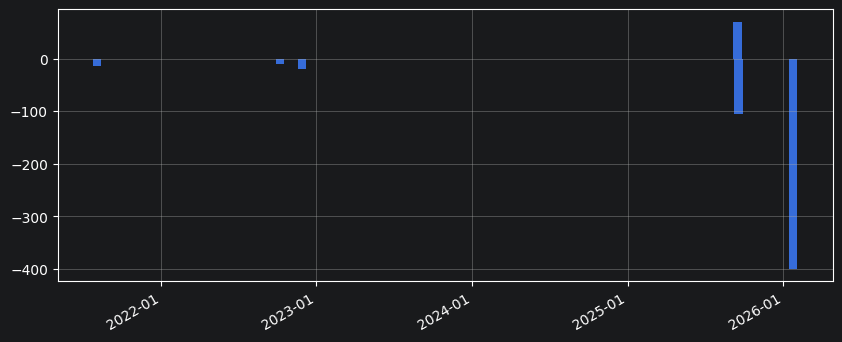

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    p2p_data['date'],
    p2p_data['amount'],
    width=20,  # width in days
)

ax.grid(True)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()

In [8]:
data.describe()

,net_amount,amount,asset_price,asset_amount,fee
count,665.000000,665.000000,543.000000,665.000000,662.000000
mean,0.103684,0.113669,4028.481197,0.143472,-0.010030
std,38.000695,37.998703,15959.481843,0.335808,0.055201
min,-400.000000,-400.000000,2.220000,0.000000,-0.500000
25%,-10.000000,-10.000000,56.165000,0.009550,0.000000
50%,-10.000000,-10.000000,131.870000,0.045980,0.000000
75%,-1.000000,-1.000000,302.100000,0.127650,0.000000
max,200.000000,200.000000,80346.140000,4.509170,0.000000


In [9]:
data.nunique().sort_values(ascending=False)

asset_price     534
asset_amount    530
date            524
notes           384
asset_type      167
amount           60
net_amount       59
trans_type       10
trans_id          7
fee               6
account           5
name_trans        5
status            2
currency          1
dtype: int64

In [10]:
data['asset_type'].value_counts().head(25)

asset_type
BTC      30
XYZ      13
JPM      12
META     11
WFC      11
V        10
MCD      10
AMZN     10
PZZA     10
ORCL     10
MSFT      8
GOOG      8
VONV      8
GOOGL     8
UBER      8
DELL      7
FISV      7
HOOD      7
DOW       7
INTU      6
PYPL      6
VOO       6
PD        6
VFH       6
VMBS      6
Name: count, dtype: int64

Text(0, 0.5, 'Count')

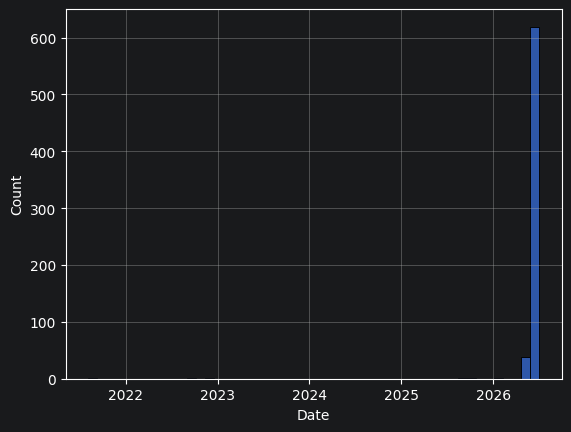

In [11]:
sns.histplot(data=data, x='date', bins=50)

plt.grid()
plt.xlabel('Date')
plt.ylabel('Count')

In [12]:
data['date'].dt.date.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame().T

,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
date,2026-04-01,2026-05-27,2026-05-29,2026-06-02,2026-06-03,2026-06-16,2026-06-26,2026-07-01,2026-07-02


In [13]:
(data
 .groupby('asset_type')
 ['amount']
 .apply(tuple)
 .to_frame()
 .assign(number=lambda df: df['amount'].apply(len))
 .assign(total=lambda df: df['amount'].apply(sum))
 .assign(amounts=lambda df: df['amount'].apply(frozenset).apply(sorted).apply(tuple))
 .drop(columns=['amount'])
 .assign(uniq_amounts=lambda df: df['amounts'].apply(len))
 .sort_values(by='number', ascending=False)
 .head(25)
 )

,number,total,amounts,uniq_amounts
asset_type,,,,
BTC,30,-166.96,"(-24.5, -9.8, -4.9, -0.98, 5.0, 10.0, 20.0)",7
XYZ,13,-171.00,"(-50.0, -25.0, -20.0, -10.0, -5.0, -1.0, 10.0)",7
JPM,12,-70.00,"(-25.0, -10.0, -5.0, 10.0, 20.0)",5
WFC,11,-51.00,"(-25.0, -10.0, -5.0, -1.0, 10.0, 20.0)",6
META,11,-80.95,"(-10.0, -5.0, -1.0, 0.05)",4
AMZN,10,-161.00,"(-50.0, -25.0, -10.0, -1.0)",4
V,10,-81.00,"(-25.0, -20.0, -10.0, -5.0, -1.0, 20.0)",6
ORCL,10,-85.00,"(-10.0, -5.0)",2
PZZA,10,-85.00,"(-25.0, -10.0, -5.0, 10.0)",4


In [14]:
data['currency'].value_counts()

currency
USD    665
Name: count, dtype: int64

In [15]:
data['trans_type'].value_counts()

trans_type
Stock Buy                    468
Deposits                      65
Stock Sell                    45
Stock Dividends               35
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                   6
P2P                            6
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [16]:
top_assets = (
    data
    .pivot_table(index='asset_type', columns='trans_type', aggfunc='count',
                 values='net_amount', fill_value=0,
                 margins=True, margins_name='total')
    .sort_values(by='total', ascending=False)
    .head(40)
)
top_assets

trans_type,Bitcoin Buy,Bitcoin Sell,Stock Buy,Stock Dividends,Stock Sell,total
asset_type,,,,,,
total,24,6,468,35,45,578
BTC,24,6,0,0,0,30
XYZ,0,0,12,0,1,13
JPM,0,0,10,0,2,12
WFC,0,0,9,0,2,11
META,0,0,10,1,0,11
AMZN,0,0,10,0,0,10
MCD,0,0,9,1,0,10
PZZA,0,0,9,0,1,10


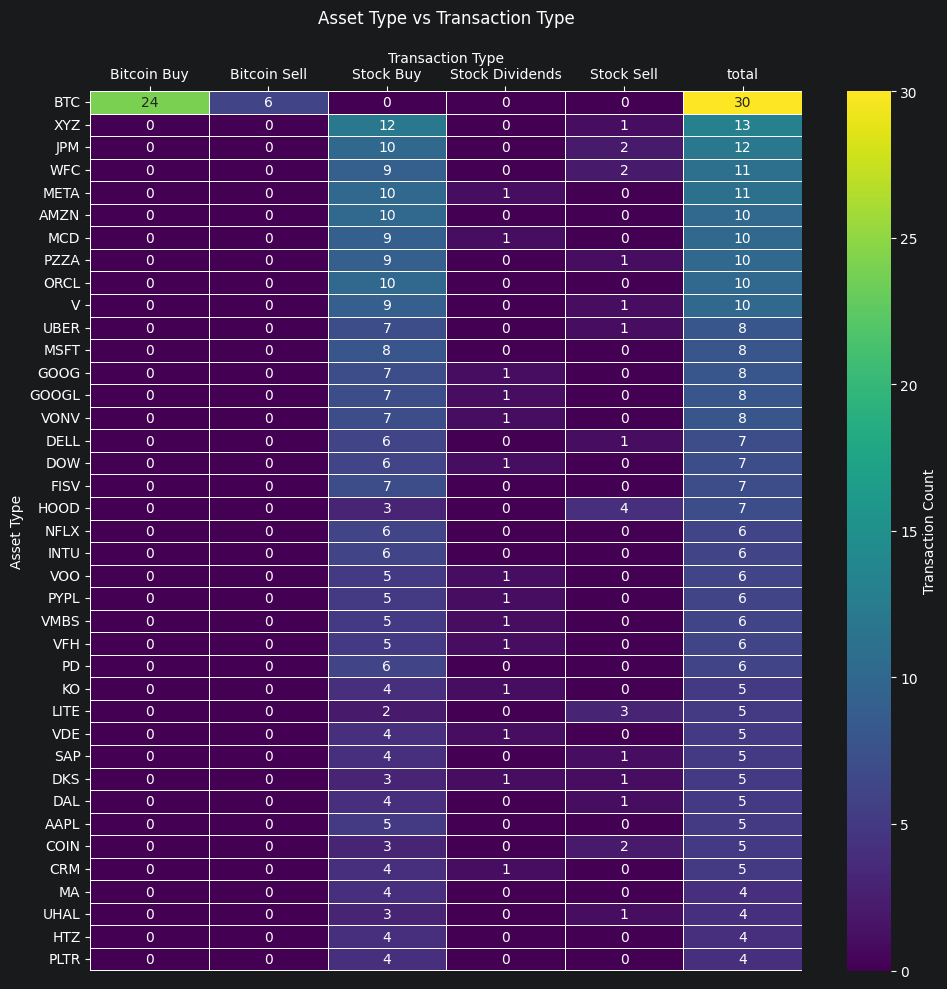

In [17]:
top_assets_heat = top_assets.drop(index='total', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    top_assets_heat,
    annot=True,
    fmt='g',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Transaction Count'},
    ax=ax,
)

ax.set_title('Asset Type vs Transaction Type', pad=20)
ax.set_ylabel('Asset Type', rotation=90)
ax.set_xlabel('Transaction Type', rotation=0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()


In [18]:
data_btc = data[data['asset_type'] == 'BTC']
data_btc.head()

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
0,2026-07-02 17:10:19+00:00,19.6,20.0,61217.07,0.000327,-0.4,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00032671,NaN
28,2026-07-01 14:21:49+00:00,-10.0,-9.8,60409.85,0.000162,-0.2,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00016223,NaN
65,2026-06-26 17:38:10+00:00,-5.0,-4.9,60331.07,0.000081,-0.1,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00008122,NaN
120,2026-06-20 20:54:15+00:00,9.8,10.0,63371.65,0.000158,-0.2,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015780,NaN
122,2026-06-20 11:51:40+00:00,-5.0,-4.9,64191.63,0.000076,-0.1,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00007633,NaN


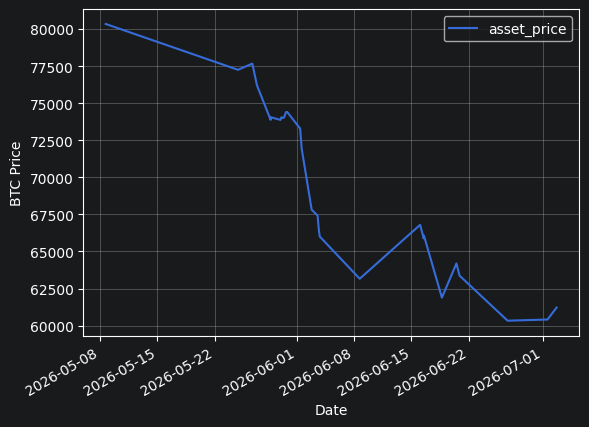

In [19]:
data_btc.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.grid()

In [20]:
data_btc['trans_type'].value_counts()

trans_type
Bitcoin Buy     24
Bitcoin Sell     6
Name: count, dtype: int64

In [21]:
data_btc.pivot_table(index='trans_type', aggfunc='sum', values='net_amount')

,net_amount
trans_type,
Bitcoin Buy,-252.0
Bitcoin Sell,78.4


In [22]:
data_btc['net_amount'].sum()

np.float64(-173.6)

In [23]:
trans_btc = data_btc.pivot_table(index='trans_type', aggfunc='sum', values='asset_amount')['asset_amount']
trans_btc

trans_type
Bitcoin Buy     0.003420
Bitcoin Sell    0.001276
Name: asset_amount, dtype: float64

In [24]:
data_btc['asset_amount'].sum()

np.float64(0.00469551)

In [25]:
btc_amount = trans_btc['Bitcoin Buy'] - trans_btc['Bitcoin Sell']
btc_amount

np.float64(0.00214373)

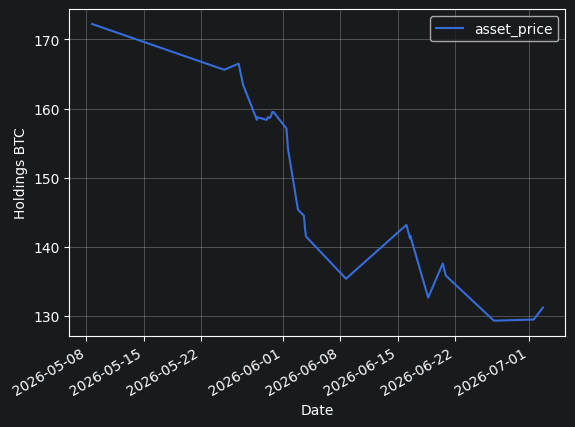

In [26]:
data_btc.assign(asset_price=lambda x: btc_amount * x['asset_price']).plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Holdings BTC')
plt.grid()

In [27]:
data_btc['asset_price'] * data_btc['asset_amount']

0      20.000229
28      9.800290
65      4.900090
120    10.000046
122     4.899747
131    19.999846
213     5.000156
214     4.999899
217     4.900240
253    19.999798
333     9.799846
360     9.800287
384     0.980144
481     9.800221
492     0.979969
509     9.799652
567     4.900136
569     9.799865
572     4.900112
573     9.799903
577     9.799965
581    24.500200
588    24.499951
592    24.500084
611     9.799731
615     9.800031
638    24.499991
655     9.799898
656     4.900356
657     9.799819
dtype: float64

In [28]:
data_xyz = data[data['asset_type'] == 'XYZ']
data_xyz

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
64,2026-06-26 17:43:48+00:00,-10.0,-10.0,77.24,0.12946,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
93,2026-06-22 13:33:13+00:00,10.0,10.0,74.28,0.13462,0.0,XYZ,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$10 Sale of Block,NaN
175,2026-06-16 13:31:47+00:00,-5.0,-5.0,74.95,0.06671,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Block,NaN
220,2026-06-15 13:32:07+00:00,-10.0,-10.0,72.26,0.13838,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
268,2026-06-04 13:31:36+00:00,-20.0,-20.0,70.84,0.28232,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
344,2026-06-03 19:22:37+00:00,-10.0,-10.0,69.87,0.14312,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
356,2026-06-03 16:57:03+00:00,-10.0,-10.0,69.67,0.14353,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
369,2026-06-03 15:50:14+00:00,-10.0,-10.0,69.62,0.14364,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
407,2026-06-03 13:43:52+00:00,-10.0,-10.0,71.59,0.13968,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
410,2026-06-03 13:33:56+00:00,-1.0,-1.0,72.82,0.01373,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$1 Purchase of Block,NaN


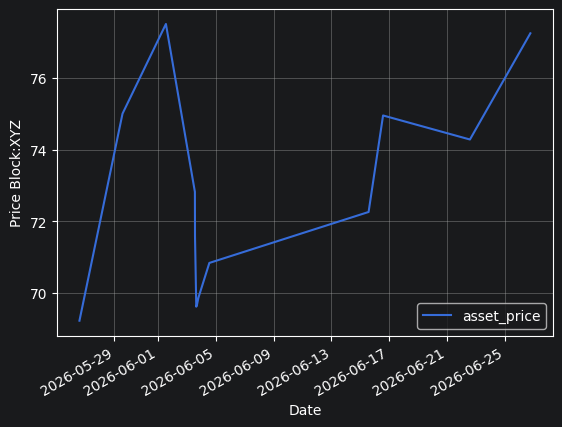

In [29]:
data_xyz.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Price Block:XYZ')
plt.grid()

In [30]:
asset_count = data.groupby('asset_type')['amount'].count().sort_values(ascending=False)
asset_count

asset_type
BTC     30
XYZ     13
JPM     12
WFC     11
META    11
        ..
UNFI     1
UNH      1
CG       1
ABNB     1
ZG       1
Name: amount, Length: 167, dtype: int64

In [31]:
asset_price = data.pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_price').bfill(axis=0)
asset_price.head()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08 16:42:34+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-24 19:57:02+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:06:39+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:09:07+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-27 03:38:54+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,75.00,149.54,42.9,36.36,36.25


In [32]:
data['asset_amount'].describe()

count    665.000000
mean       0.143472
std        0.335808
min        0.000000
25%        0.009550
50%        0.045980
75%        0.127650
max        4.509170
Name: asset_amount, dtype: float64

In [33]:
stock_amount_direction = {'Stock Sell': -1, 'Stock Buy': 1}
asset_holding_time = (
    data
    .assign(stock_direction=lambda x: x['trans_type'].map(stock_amount_direction))
    .assign(asset_amount=lambda x: x['asset_amount'] * x['stock_direction'])
    .pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_amount')
    .fillna(0)
    .cumsum(axis=0)
    .mul(asset_price, axis=1)
    .dropna(how='all')
    .ffill(axis=0)
)
asset_holding_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-02 13:30:02+00:00,47.937087,9.999493,16.180396,9.9981,0.000000,9.999577,20.893584,21.050186,9.042617,30.069556,...,6.862441,55.498870,23.724046,37.761938,0.0,181.056739,52.997013,19.954137,9.999727,9.999925
2026-06-01 13:30:28+00:00,0.000000,0.000000,0.000000,9.9981,9.998914,0.000000,9.549584,0.000000,14.039852,0.000000,...,0.000000,4.945656,0.000000,9.555644,0.0,74.055125,0.000000,0.000000,0.000000,0.000000
2026-06-03 19:38:07+00:00,20.147721,9.999493,9.010079,9.9981,19.320923,9.999577,20.893584,0.000000,14.039852,0.000000,...,0.000000,63.030258,18.724670,27.762524,0.0,131.892037,30.191289,9.953370,0.000000,0.000000
2026-06-02 16:52:54+00:00,10.217560,0.000000,0.000000,9.9981,10.098907,0.000000,9.549584,0.000000,14.039852,0.000000,...,0.000000,30.766264,0.000000,19.992722,0.0,93.073427,0.000000,0.000000,0.000000,0.000000
2026-06-04 13:30:12+00:00,20.147721,9.999493,9.010079,9.9981,19.320923,9.999577,20.893584,0.000000,14.039852,20.071824,...,0.000000,63.030258,18.724670,27.762524,0.0,131.892037,30.191289,9.953370,9.999727,9.999925
2026-06-04 13:30:21+00:00,20.147721,9.999493,9.010079,9.9981,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000,63.030258,18.724670,27.762524,0.0,131.892037,30.191289,9.953370,9.999727,9.999925
2026-06-16 15:44:16+00:00,28.691891,9.999493,11.181242,9.9981,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000,81.303113,18.724670,27.762524,0.0,174.501547,30.191289,9.953370,9.999727,9.999925
2026-06-18 17:15:27+00:00,28.691891,9.999493,16.180396,9.9981,0.000000,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000,85.406771,23.724046,27.762524,0.0,174.501547,30.191289,9.953370,9.999727,9.999925
2026-07-01 14:23:27+00:00,47.937087,9.999493,16.180396,9.9981,0.000000,9.999577,20.893584,21.050186,9.042617,30.069556,...,6.862441,55.498870,23.724046,37.761938,0.0,181.056739,42.997334,19.954137,9.999727,9.999925


In [34]:
asset_holding_time.iloc[-1].sum(axis=0)

np.float64(3853.8613436000005)

In [35]:
asset_price_rel = asset_holding_time.div(asset_holding_time.iloc[-1].sum(axis=0))
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-02 17:06:46+00:00,0.012439,0.002595,0.004198,0.002594,0.0,0.002595,0.0,0.005462,0.002346,0.007802,...,0.001781,0.014401,0.006156,0.009798,0.0,0.046981,0.013752,0.005178,0.002595,0.002595
2026-07-02 17:07:21+00:00,0.012439,0.002595,0.004198,0.002594,0.0,0.002595,0.0,0.005462,0.002346,0.007802,...,0.001781,0.014401,0.006156,0.009798,0.0,0.046981,0.013752,0.005178,0.002595,0.002595
2026-07-02 17:07:58+00:00,0.012439,0.002595,0.004198,0.002594,0.0,0.002595,0.0,0.005462,0.002346,0.007802,...,0.001781,0.014401,0.006156,0.009798,0.0,0.046981,0.013752,0.005178,0.002595,0.002595
2026-07-02 17:08:59+00:00,0.012439,0.002595,0.004198,0.002594,0.0,0.002595,0.0,0.005462,0.002346,0.007802,...,0.001781,0.014401,0.006156,0.009798,0.0,0.046981,0.013752,0.005178,0.002595,0.002595
2026-07-02 17:10:19+00:00,0.012439,0.002595,0.004198,0.002594,0.0,0.002595,0.0,0.005462,0.002346,0.007802,...,0.001781,0.014401,0.006156,0.009798,0.0,0.046981,0.013752,0.005178,0.002595,0.002595


In [36]:
asset_price_rel.iloc[-1].describe()

count    167.000000
mean       0.005988
std        0.006962
min        0.000000
25%        0.002594
50%        0.004022
75%        0.006735
max        0.046981
Name: 2026-07-02 17:10:19+00:00, dtype: float64

In [37]:
asset_price_rel.iloc[-1].sort_values(ascending=False).head()

asset_type
XYZ     0.046981
AMZN    0.038822
MCD     0.025432
UBER    0.024953
V       0.024109
Name: 2026-07-02 17:10:19+00:00, dtype: float64

In [38]:
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-02 17:06:46+00:00,0.012439,0.002595,0.004198,0.002594,0.0,0.002595,0.0,0.005462,0.002346,0.007802,...,0.001781,0.014401,0.006156,0.009798,0.0,0.046981,0.013752,0.005178,0.002595,0.002595
2026-07-02 17:07:21+00:00,0.012439,0.002595,0.004198,0.002594,0.0,0.002595,0.0,0.005462,0.002346,0.007802,...,0.001781,0.014401,0.006156,0.009798,0.0,0.046981,0.013752,0.005178,0.002595,0.002595
2026-07-02 17:07:58+00:00,0.012439,0.002595,0.004198,0.002594,0.0,0.002595,0.0,0.005462,0.002346,0.007802,...,0.001781,0.014401,0.006156,0.009798,0.0,0.046981,0.013752,0.005178,0.002595,0.002595
2026-07-02 17:08:59+00:00,0.012439,0.002595,0.004198,0.002594,0.0,0.002595,0.0,0.005462,0.002346,0.007802,...,0.001781,0.014401,0.006156,0.009798,0.0,0.046981,0.013752,0.005178,0.002595,0.002595
2026-07-02 17:10:19+00:00,0.012439,0.002595,0.004198,0.002594,0.0,0.002595,0.0,0.005462,0.002346,0.007802,...,0.001781,0.014401,0.006156,0.009798,0.0,0.046981,0.013752,0.005178,0.002595,0.002595


In [39]:
asset_price_time = (
    data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    .dropna(how='all')
)
asset_price_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-03 19:32:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-01 14:21:12+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 14:35:31+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,78.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-01 14:17:27+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-18 17:13:02+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-18 17:14:33+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-16 13:30:11+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-15 13:32:07+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,72.26,NaN,NaN,NaN,NaN
2026-06-03 19:24:06+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
asset_price_rel = asset_price_time.div(asset_price_time.bfill().iloc[0]).ffill().fillna(1)
asset_price_rel.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-03 19:32:10+00:00,1.021803,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.012014,0.968648,0.976969,1.0,1.009245,1.000000,1.000000,1.0,1.0
2026-07-01 14:21:12+00:00,0.950374,1.0,0.719207,1.0,0.970936,1.0,0.954965,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.904346,1.0,1.115701,1.005550,0.995338,1.0,1.0
2026-06-03 14:35:31+00:00,1.021803,1.0,1.000000,1.0,1.000000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.008655,1.000000,0.955619,1.0,1.034089,1.000000,1.000000,1.0,1.0
2026-07-01 14:17:27+00:00,0.950374,1.0,0.719207,1.0,0.970936,1.0,0.954965,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.976969,1.0,1.115701,1.005550,0.995338,1.0,1.0
2026-06-18 17:13:02+00:00,1.018386,1.0,0.719207,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.082418,0.921293,0.976969,1.0,1.082623,0.997325,1.000000,1.0,1.0
2026-06-18 17:14:33+00:00,1.018386,1.0,0.719207,1.0,0.970936,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.082418,0.921293,0.976969,1.0,1.082623,0.997325,1.000000,1.0,1.0
2026-06-16 13:30:11+00:00,1.018386,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.043767,0.997325,1.000000,1.0,1.0
2026-06-15 13:32:07+00:00,1.018386,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.043767,0.997325,1.000000,1.0,1.0
2026-06-03 19:24:06+00:00,1.021803,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.012014,0.968648,0.976969,1.0,1.009245,1.000000,1.000000,1.0,1.0


Text(0, 0.5, 'Relative Value of Asset Price')

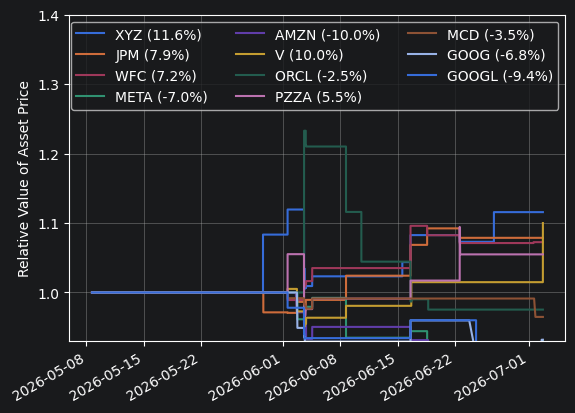

In [41]:
asset_price_rel_plot = asset_price_rel[asset_count.head(12).iloc[1::].index].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
asset_price_rel_plot.plot.line()
plt.grid()
plt.legend(ncols=3, loc='upper right')
plt.ylim(0.93, 1.4)
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [42]:
asset_price_rel['XYZ'].dropna()

date
2026-05-08 16:42:34+00:00    1.000000
2026-05-24 19:57:02+00:00    1.000000
2026-05-26 14:06:39+00:00    1.000000
2026-05-26 14:09:07+00:00    1.000000
2026-05-27 03:38:54+00:00    1.000000
                               ...   
2026-07-02 17:06:46+00:00    1.115701
2026-07-02 17:07:21+00:00    1.115701
2026-07-02 17:07:58+00:00    1.115701
2026-07-02 17:08:59+00:00    1.115701
2026-07-02 17:10:19+00:00    1.115701
Name: XYZ, Length: 421, dtype: float64

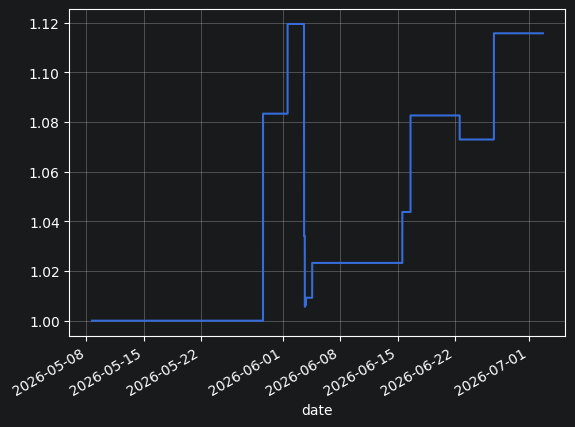

In [43]:
asset_price_rel['XYZ'].dropna().plot.line()
plt.grid()


In [44]:
div_data = (
    data[data['trans_type'] == 'Stock Dividends']
    .drop(columns=['asset_amount', 'fee', 'asset_price', 'trans_id', 'name_trans', 'account', 'currency', 'status',
                   'trans_type', 'net_amount'])
    .assign(date=lambda x: x['date'].dt.date)
)
div_data

,date,amount,asset_type,notes
18,2026-07-02,0.05,CRM,$0.05 Dividend from Salesforce
54,2026-07-01,0.27,HPQ,$0.27 Dividend from Hewlett Packard
55,2026-07-01,0.17,KO,$0.17 Dividend from Coca-Cola
56,2026-07-01,0.09,M,$0.09 Dividend from Macy's
57,2026-07-01,0.15,ADP,$0.15 Dividend from Automatic Data Processing
58,2026-07-01,0.12,PSKY,$0.12 Dividend from Paramount Skydance
59,2026-06-30,0.01,AVGO,$0.01 Dividend from Broadcom
60,2026-06-30,0.14,VBR,$0.14 Dividend from Small Cap Value ETF Vanguard
61,2026-06-30,0.02,GSLC,$0.02 Dividend from Goldman Sachs ActiveBeta U...
62,2026-06-30,0.07,VOO,$0.07 Dividend from Vanguard S&P 500 ETF


In [45]:
div_data['amount'].sum()

np.float64(3.57)

In [46]:
div_data.sort_values('amount', ascending=False)

,date,amount,asset_type,notes
69,2026-06-26,0.30,VFH,$0.30 Dividend from Vanguard Financials ETF
54,2026-07-01,0.27,HPQ,$0.27 Dividend from Hewlett Packard
76,2026-06-25,0.26,BBEU,$0.26 Dividend from JPMorgan BetaBuilders Euro...
72,2026-06-26,0.20,VDE,$0.20 Dividend from Energy ETF Vanguard
215,2026-06-16,0.20,MCD,$0.20 Dividend from McDonald's
66,2026-06-26,0.18,VNQ,$0.18 Dividend from Vanguard Real Estate ETF
55,2026-07-01,0.17,KO,$0.17 Dividend from Coca-Cola
67,2026-06-26,0.17,DKS,$0.17 Dividend from Dick's Sporting Goods
86,2026-06-23,0.16,VSS,$0.16 Dividend from Vanguard FTSE All World ex...
57,2026-07-01,0.15,ADP,$0.15 Dividend from Automatic Data Processing


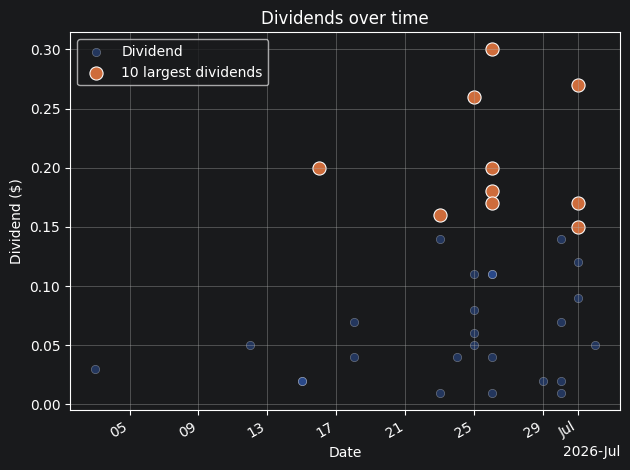

In [47]:
d = div_data.copy()
d["Date"] = pd.to_datetime(d["date"])
d = d.sort_values("date")

top10 = d.nlargest(10, "amount")

ax = sns.scatterplot(
    data=d,
    x="date",
    y="amount",
    alpha=0.35,
    label="Dividend",
)

sns.scatterplot(
    data=top10,
    x="date",
    y="amount",
    s=90,
    ax=ax,
    label="10 largest dividends",
)

for _, r in top10.iterrows():
    ax.annotate(
        r["asset_type"],
        (r["date"], r["date"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Dividends over time")
ax.set_xlabel("Date")
ax.set_ylabel("Dividend ($)")

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

ax.legend()
plt.grid()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

In [48]:
vanguard_data = (
    data[
        data['notes']
        .str.lower()
        .str.contains('vanguard')
    ]
    [['date', 'net_amount', 'asset_price', 'notes', 'asset_type']]
)
vanguard_data.sample(10, random_state=0xCAFE)


,date,net_amount,asset_price,notes,asset_type
137,2026-06-18 17:09:02+00:00,-10.00,126.88,$10 Purchase of Vanguard Russell 1000 Growth ETF,VONG
69,2026-06-26 04:00:00+00:00,0.30,NaN,$0.30 Dividend from Vanguard Financials ETF,VFH
72,2026-06-26 04:00:00+00:00,0.20,NaN,$0.20 Dividend from Energy ETF Vanguard,VDE
2,2026-07-02 17:07:58+00:00,-10.00,150.14,$10 Purchase of Energy ETF Vanguard,VDE
540,2026-06-01 13:30:16+00:00,-25.00,160.89,$25 Purchase of Energy ETF Vanguard,VDE
204,2026-06-16 13:30:05+00:00,-5.00,98.42,$5 Purchase of Vanguard Real Estate ETF,VNQ
84,2026-06-23 04:00:00+00:00,0.01,NaN,$0.01 Dividend from Vanguard Russell 1000 Grow...,VONG
439,2026-06-03 13:30:11+00:00,-10.00,390.01,$10 Purchase of Vanguard Consumer Discretionar...,VCR
391,2026-06-03 15:10:50+00:00,-10.00,48.06,$10 Purchase of Vanguard Total International B...,BNDX
71,2026-06-26 04:00:00+00:00,0.11,NaN,$0.11 Dividend from Vanguard Consumer Staples ...,VDC


In [49]:
vanguard_trans_count = vanguard_data['asset_type'].value_counts()
vanguard_trans_count

asset_type
VONV    8
VOO     6
VFH     6
VMBS    6
VDE     5
VNQ     4
VHT     4
VSS     4
VBR     3
VCR     3
VDC     3
VONG    3
BIV     2
VTEB    2
VGLT    2
BNDX    2
BSV     1
Name: count, dtype: int64

In [50]:
vanguard_note_name = (
    vanguard_data['notes']
    .pipe(lambda x: x[x.str.contains('Purchase')])
    .str.replace('.*Purchase of', '', regex=True)
)
vanguard_data_asset_names = (
    vanguard_data
    .assign(name=vanguard_note_name)
    .drop(columns=['notes'])
)
vanguard_data_asset_names.sample(10, random_state=0xCAFE)

,date,net_amount,asset_price,asset_type,name
137,2026-06-18 17:09:02+00:00,-10.00,126.88,VONG,Vanguard Russell 1000 Growth ETF
69,2026-06-26 04:00:00+00:00,0.30,NaN,VFH,NaN
72,2026-06-26 04:00:00+00:00,0.20,NaN,VDE,NaN
2,2026-07-02 17:07:58+00:00,-10.00,150.14,VDE,Energy ETF Vanguard
540,2026-06-01 13:30:16+00:00,-25.00,160.89,VDE,Energy ETF Vanguard
204,2026-06-16 13:30:05+00:00,-5.00,98.42,VNQ,Vanguard Real Estate ETF
84,2026-06-23 04:00:00+00:00,0.01,NaN,VONG,NaN
439,2026-06-03 13:30:11+00:00,-10.00,390.01,VCR,Vanguard Consumer Discretionary ETF
391,2026-06-03 15:10:50+00:00,-10.00,48.06,BNDX,Vanguard Total International Bond ETF
71,2026-06-26 04:00:00+00:00,0.11,NaN,VDC,NaN


In [51]:
vanguard_data_asset_names_trans_count = (
    vanguard_data_asset_names
    .groupby(['asset_type', 'name'])
    ['date']
    .count()
    .sort_values(ascending=False)
)
vanguard_data_asset_names_trans_count

asset_type  name                                       
VONV        Vanguard Russell 1000 Value ETF                7
VMBS        Vanguard Mortgage-Backed Securities ETF        5
VOO         Vanguard S&P 500 ETF                           5
VFH         Vanguard Financials ETF                        5
VDE         Energy ETF Vanguard                            4
VSS         Vanguard FTSE All World ex US Small Cap ETF    3
VHT         Vanguard Health Care ETF                       3
BIV         Vanguard Intermediate Term Bond ETF            2
VONG        Vanguard Russell 1000 Growth ETF               2
VNQ         Vanguard Real Estate ETF                       2
VGLT        Vanguard Long-Treasury ETF                     2
BNDX        Vanguard Total International Bond ETF          2
VDC         Vanguard Consumer Staples Index Fund ETF       2
VCR         Vanguard Consumer Discretionary ETF            2
VBR         Small Cap Value ETF Vanguard                   2
VTEB        Vanguard Tax-Exem

In [52]:
vanguard_asset_price_time = asset_holding_time = (
    vanguard_data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    [vanguard_trans_count.index]
    .dropna(how='all')
)
vanguard_asset_price_time

asset_type,VONV,VOO,VFH,VMBS,VDE,VNQ,VHT,VSS,VBR,VCR,VDC,VONG,BIV,VTEB,VGLT,BNDX,BSV
date,,,,,,,,,,,,,,,,,
2026-05-29 14:26:46+00:00,NaN,NaN,NaN,46.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,233.47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.12,NaN,NaN,NaN
2026-06-01 13:30:06+00:00,NaN,NaN,NaN,46.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,397.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:11+00:00,NaN,NaN,125.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:15+00:00,104.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:16+00:00,NaN,NaN,NaN,NaN,160.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:23+00:00,NaN,NaN,NaN,NaN,NaN,95.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
vanguard_trans_count

asset_type
VONV    8
VOO     6
VFH     6
VMBS    6
VDE     5
VNQ     4
VHT     4
VSS     4
VBR     3
VCR     3
VDC     3
VONG    3
BIV     2
VTEB    2
VGLT    2
BNDX    2
BSV     1
Name: count, dtype: int64

Text(0, 0.5, 'Relative Value of Asset Price')

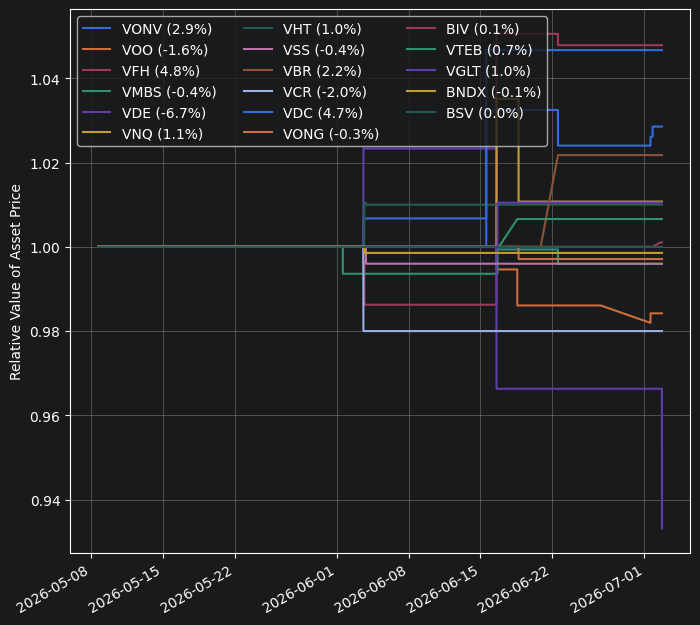

In [54]:
asset_price_rel_plot = asset_price_rel[list(vanguard_trans_count.index)].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(8, 8))

asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.legend(ncols=3, loc='upper left')
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [55]:
data_deposits = data[data['trans_type'] == 'Deposits'][['date', 'net_amount', 'account', 'status', 'notes']]
data_deposits

,date,net_amount,account,status,notes
19,2026-07-01 20:14:16+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
44,2026-07-01 13:41:36+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
119,2026-06-21 21:31:19+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
121,2026-06-20 12:23:07+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
132,2026-06-18 17:13:20+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
...,...,...,...,...,...
649,2026-05-27 00:56:27+00:00,100.0,Visa debit 5895,FAILED,Add Cash
650,2026-05-27 00:56:05+00:00,10.0,Visa debit 5895,COMPLETE,Add Cash
651,2026-05-27 00:43:01+00:00,50.0,Visa debit 5895,COMPLETE,Add Cash
652,2026-05-26 21:58:29+00:00,20.0,Visa debit 5895,COMPLETE,Add Cash


In [56]:
data_deposits['net_amount'].sum()

np.float64(5735.96)

In [57]:
data_deposits['net_amount'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
net_amount,65.0,88.245538,49.961254,1.0,50.0,100.0,100.0,200.0


In [58]:
data_deposits['net_amount'].cumsum()

19      100.00
44      200.00
119     300.00
121     400.00
132     500.00
        ...   
649    5630.96
650    5640.96
651    5690.96
652    5710.96
653    5735.96
Name: net_amount, Length: 65, dtype: float64

In [59]:
(data_deposits
.sort_values('date')
.assign(net_amount=lambda x: x['net_amount'].cumsum())
[['date', 'net_amount']]
)

,date,net_amount
653,2026-05-26 19:39:34+00:00,25.00
652,2026-05-26 21:58:29+00:00,45.00
651,2026-05-27 00:43:01+00:00,95.00
650,2026-05-27 00:56:05+00:00,105.00
649,2026-05-27 00:56:27+00:00,205.00
...,...,...
132,2026-06-18 17:13:20+00:00,5335.96
121,2026-06-20 12:23:07+00:00,5435.96
119,2026-06-21 21:31:19+00:00,5535.96
44,2026-07-01 13:41:36+00:00,5635.96


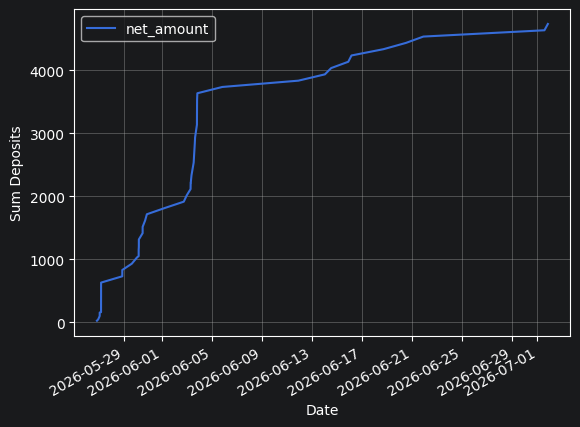

In [60]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .assign(net_amount=lambda x: x['net_amount'].cumsum())
 .plot.line(x='date', y='net_amount')
 )
plt.xlabel('Date')
plt.ylabel('Sum Deposits')
plt.grid()

In [61]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .pivot_table(index='date', columns='account', values='net_amount', aggfunc='sum', fill_value=0)
 )

account,Visa debit 3333,Visa debit 5895
date,,
2026-05-26 19:39:34+00:00,0.0,25.00
2026-05-26 21:58:29+00:00,0.0,20.00
2026-05-27 00:43:01+00:00,0.0,50.00
2026-05-27 00:56:05+00:00,0.0,10.00
2026-05-27 00:57:28+00:00,0.0,50.00
2026-05-27 03:29:11+00:00,0.0,5.00
2026-05-27 03:29:39+00:00,0.0,10.00
2026-05-27 03:30:06+00:00,0.0,10.00
2026-05-27 03:30:50+00:00,0.0,50.00


In [62]:
(data_deposits
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .groupby('account')
 ['net_amount']
 .sum()
 )

account
Visa debit 3333    4400.00
Visa debit 5895     335.96
Name: net_amount, dtype: float64